# Oppenheimer–Snyder metric time slices

This notebook compares the rewritten RadiShPICR Oppenheimer–Snyder collapse output with the presentation of the paper figures. It reads the existing metric snapshots and plots the lapse $\alpha$ and radial metric component $A$ against areal radius

$$
\frac{r_s}{M}=\frac{A(r)r}{M}.
$$

Only RadiShPICR simulation curves are shown. No paper reference solution is reconstructed, and no saved values are smoothed, sorted, offset, normalized, extrapolated, or rewritten.

## Configuration

`TOTAL_MASS` is explicit because it is fixed by the live demo but is not stored in each snapshot. The first data path is correct when Jupyter is launched from this demo directory; the second is correct when it is launched from the repository root.

In [1]:
from __future__ import annotations

from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
import numpy as np
from IPython.display import HTML, display


DATA_ROOT = Path("outputs/heun_oppenheimer_snyder")
if not DATA_ROOT.is_dir():
    DATA_ROOT = Path(
        "demos/oppenheimer_snyder_collapse/outputs/heun_oppenheimer_snyder"
    )

TOTAL_MASS = 1.0
TARGET_SCHWARZSCHILD_TIMES_OVER_MASS = np.asarray([0.0, 40.8, 46.0, 49.0])
UNAVAILABLE_PAPER_TIMES_OVER_MASS = np.asarray([51.7, 54.4, 57.1, 58.7])

PAPER_RADIUS_LIMITS = (1.0e-1, 1.0e2)
PAPER_LAPSE_LIMITS = (1.0e-4, 1.0)
PAPER_A_LIMITS = (1.0, 1.0e3)

U_STATE_DIRECTORY = DATA_ROOT / "U_state"
print(f"Reading metric snapshots from: {U_STATE_DIRECTORY.resolve()}")

Reading metric snapshots from: /home/christopherwoolford/Documents/Research/projects/radial_electrostatic_PIC_relativity/code/RadiShPICR/demos/oppenheimer_snyder_collapse/outputs/heun_oppenheimer_snyder/U_state


## Load and select the saved Schwarzschild-time slices

Each target time is matched to the nearest unique saved snapshot. The table records the actual data used. Areal-radius monotonicity is diagnosed but never repaired: in particular, the late profile is plotted in native radial-grid order rather than sorted into an artificial single-valued curve.

In [2]:
def step_from_path(path: Path) -> int:
    match = re.search(r"step_(\d+)\.npz$", path.name)
    if match is None:
        raise RuntimeError(f"Could not read a saved step from {path.name}.")
    return int(match.group(1))


def discover_snapshots(u_state_directory: Path) -> list[dict[str, object]]:
    paths = sorted(
        u_state_directory.glob("U_state_step_*.npz"),
        key=step_from_path,
    )
    if not paths:
        raise FileNotFoundError(f"No U-state snapshots found in {u_state_directory}.")

    snapshot_index = []
    for path in paths:
        with np.load(path) as data:
            snapshot_index.append({
                "path": path,
                "step": int(np.asarray(data["step"])),
                "schwarzschild_time": float(np.asarray(data["schwarzschild_time"])),
            })
    return snapshot_index


def load_metric_snapshot(index_entry: dict[str, object]) -> dict[str, object]:
    with np.load(index_entry["path"]) as data:
        r = np.asarray(data["r"])
        A = np.asarray(data["A"])
        alpha = np.asarray(data["alpha"])

    areal_radius_over_mass = A * r / TOTAL_MASS
    nonmonotone_intervals = int(
        np.count_nonzero(np.diff(areal_radius_over_mass) <= 0.0)
    )

    return {
        **index_entry,
        "time_over_mass": index_entry["schwarzschild_time"] / TOTAL_MASS,
        "r": r,
        "A": A,
        "alpha": alpha,
        "areal_radius_over_mass": areal_radius_over_mass,
        "nonmonotone_intervals": nonmonotone_intervals,
    }


def select_nearest_unique_snapshots(
    snapshot_index: list[dict[str, object]],
    target_times_over_mass: np.ndarray,
) -> list[dict[str, object]]:
    saved_times_over_mass = np.asarray([
        entry["schwarzschild_time"] / TOTAL_MASS for entry in snapshot_index
    ])

    selected = []
    selected_steps = set()
    for target_time in target_times_over_mass:
        selected_index = int(np.argmin(np.abs(saved_times_over_mass - target_time)))
        entry = dict(snapshot_index[selected_index])
        if entry["step"] in selected_steps:
            raise RuntimeError("Two target times selected the same saved snapshot.")

        snapshot = load_metric_snapshot(entry)
        snapshot["target_time_over_mass"] = float(target_time)
        snapshot["time_offset_over_mass"] = (
            snapshot["time_over_mass"] - float(target_time)
        )
        selected.append(snapshot)
        selected_steps.add(entry["step"])

    return selected


def selection_table(snapshots: list[dict[str, object]]) -> HTML:
    rows = []
    for snapshot in snapshots:
        monotonicity = (
            "strictly increasing"
            if snapshot["nonmonotone_intervals"] == 0
            else f'{snapshot["nonmonotone_intervals"]} non-monotone intervals'
        )
        rows.append(
            "<tr>"
            f'<td>{snapshot["target_time_over_mass"]:.1f}</td>'
            f'<td>{snapshot["time_over_mass"]:.7f}</td>'
            f'<td>{snapshot["step"]:06d}</td>'
            f'<td>{snapshot["time_offset_over_mass"]:+.7f}</td>'
            f"<td>{monotonicity}</td>"
            "</tr>"
        )

    return HTML(
        "<table>"
        "<thead><tr>"
        "<th>requested $t/M$</th><th>saved $t/M$</th><th>step</th>"
        "<th>offset</th><th>$r_s/M$ map</th>"
        "</tr></thead>"
        f"<tbody>{''.join(rows)}</tbody>"
        "</table>"
    )


snapshot_index = discover_snapshots(U_STATE_DIRECTORY)
selected_snapshots = select_nearest_unique_snapshots(
    snapshot_index,
    TARGET_SCHWARZSCHILD_TIMES_OVER_MASS,
)

first_time_over_mass = snapshot_index[0]["schwarzschild_time"] / TOTAL_MASS
last_time_over_mass = snapshot_index[-1]["schwarzschild_time"] / TOTAL_MASS
print(
    f"Discovered {len(snapshot_index)} snapshots spanning "
    f"t/M = {first_time_over_mass:.7f} to {last_time_over_mass:.7f}."
)
display(selection_table(selected_snapshots))

late_nonmonotone = [
    snapshot for snapshot in selected_snapshots
    if snapshot["nonmonotone_intervals"] > 0
]
if late_nonmonotone:
    warning_lines = "<br>".join(
        f'Step {snapshot["step"]:06d} at t/M={snapshot["time_over_mass"]:.7f} has '
        f'{snapshot["nonmonotone_intervals"]} non-monotone areal-radius intervals.'
        for snapshot in late_nonmonotone
    )
    display(HTML(
        '<div style="border-left: 5px solid #b36b00; padding: 0.6em 0.9em; '
        'background: #fff4df;"><b>Coordinate warning:</b><br>'
        f"{warning_lines}<br>The curves retain native radial-grid order; no sorting is applied."
        "</div>"
    ))

unavailable_text = ", ".join(
    f"{time_over_mass:.1f}" for time_over_mass in UNAVAILABLE_PAPER_TIMES_OVER_MASS
)
display(HTML(
    '<div style="margin-top: 0.8em; border-left: 5px solid #666; '
    'padding: 0.6em 0.9em; background: #f2f2f2;">'
    f"The current run ends at t/M={last_time_over_mass:.7f}. "
    f"Paper slices {unavailable_text} are unavailable and are not plotted, "
    "duplicated, or extrapolated.</div>"
))

Discovered 725 snapshots spanning t/M = 0.0000000 to 49.0302028.


requested $t/M$,saved $t/M$,step,offset,$r_s/M$ map
0.0,0.0000000,000000,+0.0000000,strictly increasing
40.8,40.8077936,000705,+0.0077936,strictly increasing
46.0,46.0815941,000711,+0.0815941,strictly increasing
49.0,49.0005201,000722,+0.0005201,5 non-monotone intervals


## Paper-style figures

Both panels retain the logarithmic limits of the supplied paper figures. Values outside those limits are clipped by the axes only; they remain unchanged in memory. Solid black lines are the RadiShPICR profiles themselves, not exact-paper curves.

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 1.3,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


def paper_log_tick(value: float, position: float) -> str:
    if value <= 0.0:
        return ""

    exponent = int(np.rint(np.log10(value)))
    if not np.isclose(value, 10.0**exponent):
        return ""
    if exponent == 0:
        return r"$1$"
    if exponent == 1:
        return r"$10$"
    return rf"$10^{{{exponent}}}$"


def configure_paper_axes(ax, y_label: str, y_limits: tuple[float, float]):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(*PAPER_RADIUS_LIMITS)
    ax.set_ylim(*y_limits)
    ax.set_xlabel(r"$r_s/M$", fontsize=18)
    ax.set_ylabel(y_label, fontsize=18, rotation=0, labelpad=25)
    ax.grid(False)
    ax.set_box_aspect(1.0)

    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(LogLocator(base=10.0))
        axis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
        axis.set_major_formatter(FuncFormatter(paper_log_tick))
        axis.set_minor_formatter(NullFormatter())

    ax.tick_params(which="major", direction="in", top=True, right=True, length=8, width=1.2)
    ax.tick_params(which="minor", direction="in", top=True, right=True, length=4, width=1.0)


def formatted_saved_time(time_over_mass: float) -> str:
    if np.isclose(time_over_mass, 0.0):
        return "0.0"
    return f"{time_over_mass:.2f}"


def annotation_index(
    radius: np.ndarray,
    values: np.ndarray,
    target_radius: float,
    y_limits: tuple[float, float],
) -> int:
    visible = (
        np.isfinite(radius)
        & np.isfinite(values)
        & (radius >= PAPER_RADIUS_LIMITS[0])
        & (radius <= PAPER_RADIUS_LIMITS[1])
        & (values >= y_limits[0])
        & (values <= y_limits[1])
    )
    visible_indices = np.flatnonzero(visible)
    if visible_indices.size == 0:
        raise RuntimeError("A selected curve has no samples inside the paper axes.")

    logarithmic_distance = np.abs(
        np.log10(radius[visible_indices]) - np.log10(target_radius)
    )
    return int(visible_indices[np.argmin(logarithmic_distance)])


def plot_metric_slices(
    snapshots: list[dict[str, object]],
    component: str,
    y_label: str,
    y_limits: tuple[float, float],
    label_radii: np.ndarray,
    time_header_position: tuple[float, float],
):
    figure, ax = plt.subplots(figsize=(7.6, 7.3))
    configure_paper_axes(ax, y_label, y_limits)

    plotted_samples = []
    for snapshot, label_radius in zip(snapshots, label_radii):
        radius = np.asarray(snapshot["areal_radius_over_mass"])
        values = np.asarray(snapshot[component])
        plot_mask = (
            np.isfinite(radius)
            & np.isfinite(values)
            & (radius > 0.0)
            & (values > 0.0)
        )

        line = ax.plot(
            radius[plot_mask],
            values[plot_mask],
            color="black",
            linewidth=1.35,
            linestyle="-",
            solid_capstyle="round",
        )[0]
        plotted_samples.append((line, radius[plot_mask], values[plot_mask]))

        label_index = annotation_index(radius, values, label_radius, y_limits)
        ax.annotate(
            formatted_saved_time(snapshot["time_over_mass"]),
            xy=(radius[label_index], values[label_index]),
            xytext=(5, 4),
            textcoords="offset points",
            fontsize=13,
            color="black",
        )

    ax.text(
        *time_header_position,
        r"$t/M =$",
        transform=ax.transAxes,
        ha="left",
        va="center",
        fontsize=15,
    )
    figure.tight_layout()
    return figure, ax, plotted_samples

### Lapse $\alpha(r_s/M)$

t/M=46.0815941: 48 positive lapse samples lie below the paper limit alpha=1e-04.


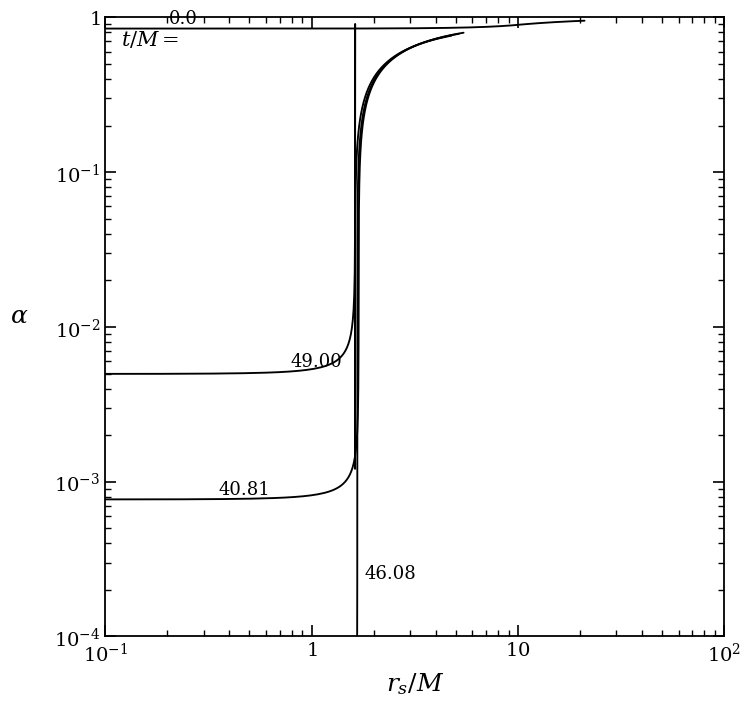

In [4]:
lapse_figure, lapse_axes, lapse_samples = plot_metric_slices(
    selected_snapshots,
    component="alpha",
    y_label=r"$\alpha$",
    y_limits=PAPER_LAPSE_LIMITS,
    label_radii=np.asarray([0.17, 0.33, 0.75, 0.75]),
    time_header_position=(0.025, 0.965),
)

for snapshot in selected_snapshots:
    clipped_samples = int(np.count_nonzero(
        np.asarray(snapshot["alpha"]) < PAPER_LAPSE_LIMITS[0]
    ))
    if clipped_samples:
        print(
            f't/M={snapshot["time_over_mass"]:.7f}: {clipped_samples} positive lapse '
            f"samples lie below the paper limit alpha={PAPER_LAPSE_LIMITS[0]:.0e}."
        )

plt.show()

### Radial metric component $A(r_s/M)$

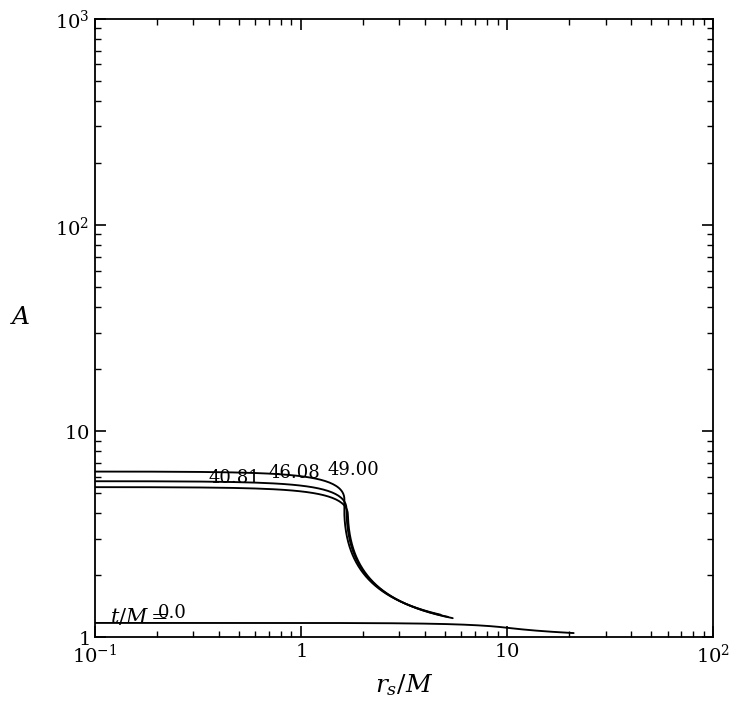

In [5]:
A_figure, A_axes, A_samples = plot_metric_slices(
    selected_snapshots,
    component="A",
    y_label=r"$A$",
    y_limits=PAPER_A_LIMITS,
    label_radii=np.asarray([0.17, 0.33, 0.65, 1.25]),
    time_header_position=(0.025, 0.035),
)
plt.show()

## Reproducibility checks

These checks verify the plotting contract without changing the data: four solid black profiles per figure, fixed paper axes, and plotted horizontal coordinates equal to the direct $A r/M$ conversion in native grid order.

In [6]:
def verify_figure(
    ax,
    plotted_samples,
    y_limits: tuple[float, float],
):
    assert len(ax.lines) == len(selected_snapshots) == 4
    assert ax.get_xscale() == "log"
    assert ax.get_yscale() == "log"
    np.testing.assert_allclose(ax.get_xlim(), PAPER_RADIUS_LIMITS)
    np.testing.assert_allclose(ax.get_ylim(), y_limits)

    for line, plotted_radius, plotted_values in plotted_samples:
        assert line.get_color() == "black"
        assert line.get_linestyle() == "-"
        assert line.get_marker() == "None"
        np.testing.assert_array_equal(line.get_xdata(), plotted_radius)
        np.testing.assert_array_equal(line.get_ydata(), plotted_values)


verify_figure(lapse_axes, lapse_samples, PAPER_LAPSE_LIMITS)
verify_figure(A_axes, A_samples, PAPER_A_LIMITS)

saved_times = np.asarray([
    snapshot["time_over_mass"] for snapshot in selected_snapshots
])
expected_saved_times = np.asarray([
    0.0,
    40.80779359823717,
    46.08159412531853,
    49.0005201182611,
])
np.testing.assert_allclose(saved_times, expected_saved_times, rtol=0.0, atol=1.0e-12)

for snapshot in selected_snapshots:
    expected_radius = snapshot["A"] * snapshot["r"] / TOTAL_MASS
    np.testing.assert_array_equal(snapshot["areal_radius_over_mass"], expected_radius)

print("Notebook checks passed: direct data mapping and paper-style figure contracts verified.")

Notebook checks passed: direct data mapping and paper-style figure contracts verified.


## Interpretation boundary

The visual differences from the supplied paper figures are simulation results, not plotting corrections. The $t/M\approx49$ curve includes the saved non-monotone areal-radius mapping, and later paper times are absent because this run does not contain them.